<a href="https://colab.research.google.com/github/Wizako-01/A-Comparative-Study-of-Convolutional-Neural-Networks-and-ViT-for-Cervical-Cytology-Classification/blob/main/Hepatocellular_carcinoma_work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =========================
# 1. IMPORT LIBRARIES
# =========================

import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Evaluation metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# For displaying images
from PIL import Image

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: []


In [2]:
# =========================
# 3. DEFINE DATA PATHS
# =========================

base_dir = "/content/drive/MyDrive/split_for_train"
train_dir = "/content/drive/MyDrive/split_for_train/train"
val_dir = "/content/drive/MyDrive/split_for_train/val"
test_dir = "/content/drive/MyDrive/split_for_train/test"

print("Base directory exists:", os.path.exists(base_dir))
print("Train directory exists:", os.path.exists(train_dir))
print("Validation directory exists:", os.path.exists(val_dir))
print("Test directory exists:", os.path.exists(test_dir))

Base directory exists: True
Train directory exists: True
Validation directory exists: True
Test directory exists: True


In [3]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: []


In [4]:
# =========================
# CHECK IMAGE COUNTS
# =========================

import os
from pathlib import Path

base_dir = "/content/drive/MyDrive/split_for_train"

valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

for split in ["train", "val", "test"]:
    split_path = Path(base_dir) / split

    print(f"\n{split.upper()}")
    print("-" * 30)

    if not split_path.exists():
        print(f"{split} folder not found")
        continue

    total_split = 0

    for class_folder in sorted(split_path.iterdir()):
        if class_folder.is_dir():
            image_count = sum(
                1 for file in class_folder.rglob("*")
                if file.suffix.lower() in valid_exts
            )
            total_split += image_count
            print(f"{class_folder.name}: {image_count}")

    print(f"Total {split}: {total_split}")


TRAIN
------------------------------
HCC: 1901
Hemangioma: 1868
Total train: 3769

VAL
------------------------------
HCC: 543
Hemangioma: 533
Total val: 1076

TEST
------------------------------
HCC: 272
Hemangioma: 268
Total test: 540


In [5]:
# =========================
# LOAD IMAGE DATASETS
# =========================

import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_dir = "/content/drive/MyDrive/split_for_train/train"
val_dir = "/content/drive/MyDrive/split_for_train/val"
test_dir = "/content/drive/MyDrive/split_for_train/test"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

class_names = train_ds.class_names
print("Class names:", class_names)

Found 3769 files belonging to 2 classes.
Found 1076 files belonging to 2 classes.
Found 540 files belonging to 2 classes.
Class names: ['HCC', 'Hemangioma']


In [6]:
# =========================
# OPTIMIZE DATA PIPELINE
# =========================

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Data pipeline ready.")

Data pipeline ready.


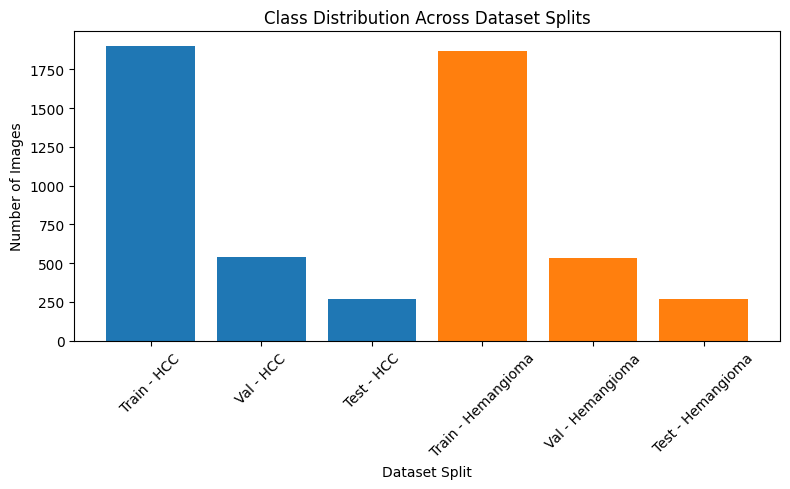

,Split,Class,Count
0,Train,HCC,1901
1,Train,Hemangioma,1868
2,Val,HCC,543
3,Val,Hemangioma,533
4,Test,HCC,272
5,Test,Hemangioma,268


In [7]:
# =========================
# VISUALIZE CLASS COUNTS
# =========================

import matplotlib.pyplot as plt
import pandas as pd

counts = {
    "Split": ["Train", "Train", "Val", "Val", "Test", "Test"],
    "Class": ["HCC", "Hemangioma", "HCC", "Hemangioma", "HCC", "Hemangioma"],
    "Count": [1901, 1868, 543, 533, 272, 268]
}

df_counts = pd.DataFrame(counts)

plt.figure(figsize=(8, 5))

for cls in df_counts["Class"].unique():
    subset = df_counts[df_counts["Class"] == cls]
    plt.bar(
        subset["Split"] + " - " + subset["Class"],
        subset["Count"]
    )

plt.title("Class Distribution Across Dataset Splits")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df_counts

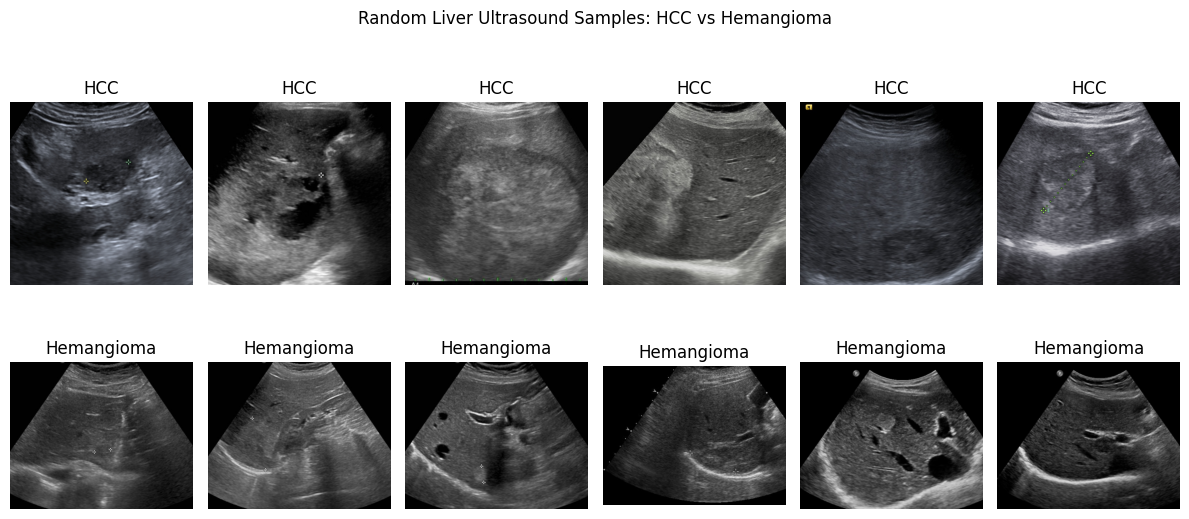

In [8]:
# =========================
# DISPLAY RANDOM SAMPLE IMAGES BY CLASS
# =========================

import os
import random
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

train_dir = Path("/content/drive/MyDrive/split_for_train/train")

classes = ["HCC", "Hemangioma"]
num_images_per_class = 6

plt.figure(figsize=(12, 6))

plot_index = 1

for cls in classes:
    class_path = train_dir / cls
    image_files = list(class_path.rglob("*"))
    image_files = [f for f in image_files if f.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]]

    selected_images = random.sample(image_files, num_images_per_class)

    for img_path in selected_images:
        img = Image.open(img_path).convert("RGB")

        plt.subplot(len(classes), num_images_per_class, plot_index)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")

        plot_index += 1

plt.suptitle("Random Liver Ultrasound Samples: HCC vs Hemangioma")
plt.tight_layout()
plt.show()

In [9]:
# =========================
# IMAGE SIZE DISTRIBUTION
# =========================

from pathlib import Path
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt

base_dir = Path("/content/drive/MyDrive/split_for_train")

valid_exts = [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]

image_info = []

for split in ["train", "val", "test"]:
    split_path = base_dir / split

    for cls in ["HCC", "Hemangioma"]:
        class_path = split_path / cls

        for img_path in class_path.rglob("*"):
            if img_path.suffix.lower() in valid_exts:
                try:
                    img = Image.open(img_path)
                    width, height = img.size

                    image_info.append({
                        "split": split,
                        "class": cls,
                        "width": width,
                        "height": height,
                        "path": str(img_path)
                    })

                except Exception as e:
                    print("Error reading:", img_path, e)

df_images = pd.DataFrame(image_info)

print(df_images.head())
print("\nTotal images checked:", len(df_images))

print("\nImage size summary:")
print(df_images[["width", "height"]].describe())

   split class  width  height  \
0  train   HCC    512     512   
1  train   HCC    512     512   
2  train   HCC    512     512   
3  train   HCC    512     512   
4  train   HCC    512     512   

                                                path  
0  /content/drive/MyDrive/split_for_train/train/H...  
1  /content/drive/MyDrive/split_for_train/train/H...  
2  /content/drive/MyDrive/split_for_train/train/H...  
3  /content/drive/MyDrive/split_for_train/train/H...  
4  /content/drive/MyDrive/split_for_train/train/H...  

Total images checked: 5385

Image size summary:
             width       height
count  5385.000000  5385.000000
mean    615.690808   544.877623
std     117.895460    57.497752
min     353.000000   341.000000
25%     512.000000   512.000000
50%     512.000000   512.000000
75%     735.000000   592.000000
max    1051.000000   848.000000


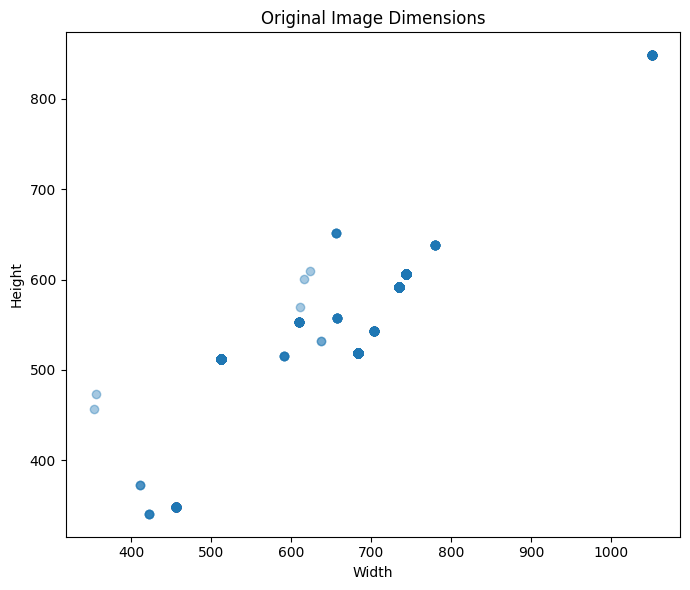

In [10]:
# =========================
# SCATTER PLOT OF IMAGE DIMENSIONS
# =========================

plt.figure(figsize=(7, 6))
plt.scatter(df_images["width"], df_images["height"], alpha=0.4)
plt.title("Original Image Dimensions")
plt.xlabel("Width")
plt.ylabel("Height")
plt.tight_layout()
plt.show()

In [11]:
# =========================
# IMAGE SIZE SUMMARY BY CLASS
# =========================

df_images.groupby("class")[["width", "height"]].describe()

width                                                             \
             count        mean        std    min    25%    50%    75%     max   
class                                                                           
HCC         2716.0  512.000000   0.000000  512.0  512.0  512.0  512.0   512.0   
Hemangioma  2669.0  721.207568  77.237059  353.0  735.0  735.0  735.0  1051.0   

            height                                                            
             count        mean        std    min    25%    50%    75%    max  
class                                                                         
HCC         2716.0  512.000000   0.000000  512.0  512.0  512.0  512.0  512.0  
Hemangioma  2669.0  578.334208  66.718163  341.0  592.0  592.0  592.0  848.0

In [12]:
# =========================
# TRAINING CONSTANTS
# =========================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
SEED = 42

num_classes = 1  # binary classification: HCC vs Hemangioma

In [13]:
# =========================
# DATA AUGMENTATION
# =========================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

In [14]:
# =========================
# BUILD EFFICIENTNETB0 MODEL
# =========================

from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# Freeze the pretrained base first
base_model.trainable = False

inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [15]:
# =========================
# COMPILE MODEL
# =========================

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.AUC(name="auc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

In [16]:
# =========================
# CALLBACKS
# =========================

checkpoint_path = "/content/drive/MyDrive/best_effnetb0_smc_lud.keras"

callbacks = [
    ModelCheckpoint(
        checkpoint_path,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

In [17]:
# =========================
# TRAIN MODEL
# =========================

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6855 - auc: 0.7578 - loss: 0.5749 - precision: 0.6652 - recall: 0.7067
Epoch 1: val_auc improved from None to 0.97202, saving model to /content/drive/MyDrive/best_effnetb0_smc_lud.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_effnetb0_smc_lud.keras
118/118 ━━━━━━━━━━━━━━━━━━━━ 412s 3s/step - accuracy: 0.7822 - auc: 0.8766 - loss: 0.4740 - precision: 0.7678 - recall: 0.8035 - val_accuracy: 0.9182 - val_auc: 0.9720 - val_loss: 0.3016 - val_precision: 0.9513 - val_recall: 0.8799 - learning_rate: 0.0010
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8908 - auc: 0.9535 - loss: 0.3211 - precision: 0.8776 - recall: 0.8988
Epoch 2: val_auc improved from 0.97202 to 0.98041, saving model to /content/drive/MyDrive/best_effnetb0_smc_lud.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_effnetb0_smc_lud.keras
118/118 ━━━━━━━━━━━━━━━━━━━━ 389s 3s/step - accuracy: 0.9000 - auc:

KeyboardInterrupt: 

In [18]:
# =========================
# LOAD BEST SAVED MODEL
# =========================

best_model_path = "/content/drive/MyDrive/best_effnetb0_smc_lud.keras"

best_model = keras.models.load_model(best_model_path)

print("Best model loaded successfully.")

Best model loaded successfully.


Best model loaded successfully.
Found 540 files belonging to 2 classes.
Class names: ['HCC', 'Hemangioma']
Important: 0 = HCC, 1 = Hemangioma

Prediction complete.
Number of test images: 540

TEST SET PERFORMANCE
Accuracy: 0.9241
AUC: 0.9943

HCC metrics:
HCC precision: 0.8738
HCC sensitivity/recall: 0.9926
HCC F1-score: 0.9294

Hemangioma metrics:
Hemangioma precision: 0.9913
Hemangioma sensitivity/recall: 0.8545
Hemangioma F1-score: 0.9178

Confusion Matrix:
[[270   2]
 [ 39 229]]

Classification Report:
              precision    recall  f1-score   support

         HCC       0.87      0.99      0.93       272
  Hemangioma       0.99      0.85      0.92       268

    accuracy                           0.92       540
   macro avg       0.93      0.92      0.92       540
weighted avg       0.93      0.92      0.92       540



,Metric,Value
0,Accuracy,0.924074
1,AUC,0.994293
2,HCC Precision,0.873786
3,HCC Sensitivity/Recall,0.992647
4,HCC F1-score,0.929432
5,Hemangioma Precision,0.991342
6,Hemangioma Sensitivity/Recall,0.854478
7,Hemangioma F1-score,0.917836



Metrics saved to: /content/drive/MyDrive/smc_lud_test_metrics.csv


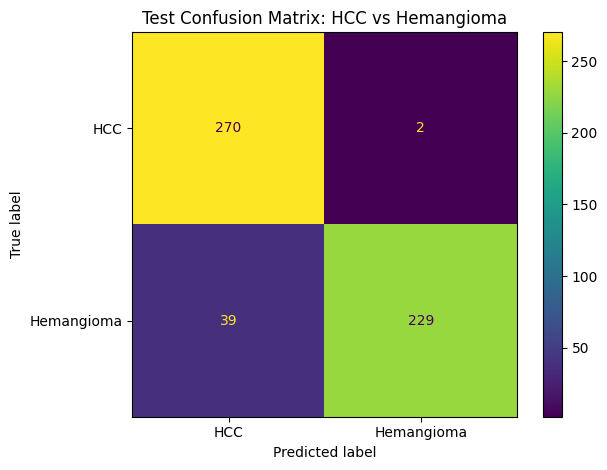

Confusion matrix saved to: /content/drive/MyDrive/smc_lud_confusion_matrix.png


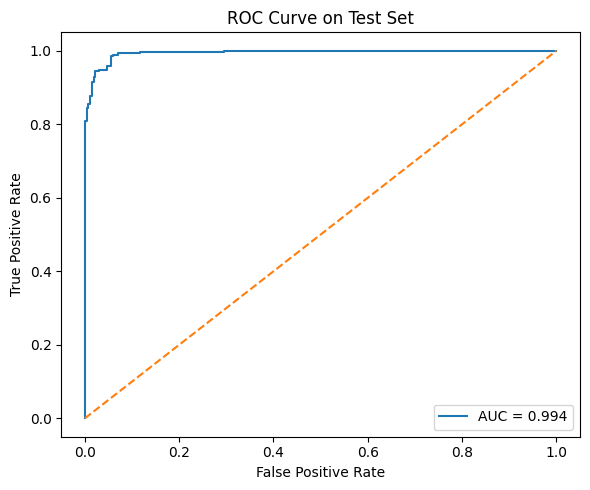

ROC curve saved to: /content/drive/MyDrive/smc_lud_roc_curve.png


In [2]:
# =========================
# TEST BEST SAVED MODEL
# =========================

import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

# -------------------------
# 1. Load best saved model
# -------------------------

best_model_path = "/content/drive/MyDrive/best_effnetb0_smc_lud.keras"

best_model = keras.models.load_model(best_model_path)

print("Best model loaded successfully.")


# -------------------------
# 2. Load test dataset
# -------------------------

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

test_dir = "/content/drive/MyDrive/split_for_train/test"

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

class_names = test_ds.class_names
print("Class names:", class_names)
print("Important: 0 = HCC, 1 = Hemangioma")


# -------------------------
# 3. Predict on test set
# -------------------------

y_true = []
y_prob = []

for images, labels in test_ds:
    probs = best_model.predict(images, verbose=0)
    y_prob.extend(probs.ravel())
    y_true.extend(labels.numpy().ravel())

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)

# Sigmoid output: probability closer to 1 = Hemangioma
y_pred = (y_prob >= 0.5).astype(int)

print("\nPrediction complete.")
print("Number of test images:", len(y_true))


# -------------------------
# 4. Calculate metrics
# -------------------------

acc = accuracy_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)

# Hemangioma is positive class because label 1 = Hemangioma
precision_hema = precision_score(y_true, y_pred, pos_label=1)
recall_hema = recall_score(y_true, y_pred, pos_label=1)
f1_hema = f1_score(y_true, y_pred, pos_label=1)

# HCC as positive class using pos_label=0
precision_hcc = precision_score(y_true, y_pred, pos_label=0)
recall_hcc = recall_score(y_true, y_pred, pos_label=0)  # HCC sensitivity
f1_hcc = f1_score(y_true, y_pred, pos_label=0)

cm = confusion_matrix(y_true, y_pred)

print("\n=========================")
print("TEST SET PERFORMANCE")
print("=========================")
print(f"Accuracy: {acc:.4f}")
print(f"AUC: {auc:.4f}")

print("\nHCC metrics:")
print(f"HCC precision: {precision_hcc:.4f}")
print(f"HCC sensitivity/recall: {recall_hcc:.4f}")
print(f"HCC F1-score: {f1_hcc:.4f}")

print("\nHemangioma metrics:")
print(f"Hemangioma precision: {precision_hema:.4f}")
print(f"Hemangioma sensitivity/recall: {recall_hema:.4f}")
print(f"Hemangioma F1-score: {f1_hema:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


# -------------------------
# 5. Save metrics as table
# -------------------------

results_table = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "AUC",
        "HCC Precision",
        "HCC Sensitivity/Recall",
        "HCC F1-score",
        "Hemangioma Precision",
        "Hemangioma Sensitivity/Recall",
        "Hemangioma F1-score"
    ],
    "Value": [
        acc,
        auc,
        precision_hcc,
        recall_hcc,
        f1_hcc,
        precision_hema,
        recall_hema,
        f1_hema
    ]
})

display(results_table)

results_table.to_csv("/content/drive/MyDrive/smc_lud_test_metrics.csv", index=False)
print("\nMetrics saved to: /content/drive/MyDrive/smc_lud_test_metrics.csv")


# -------------------------
# 6. Plot confusion matrix
# -------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(values_format="d")
plt.title("Test Confusion Matrix: HCC vs Hemangioma")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/smc_lud_confusion_matrix.png", dpi=300)
plt.show()

print("Confusion matrix saved to: /content/drive/MyDrive/smc_lud_confusion_matrix.png")


# -------------------------
# 7. Plot ROC curve
# -------------------------

fpr, tpr, thresholds = roc_curve(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Test Set")
plt.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/smc_lud_roc_curve.png", dpi=300)
plt.show()

print("ROC curve saved to: /content/drive/MyDrive/smc_lud_roc_curve.png")

TensorFlow GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found 3769 files belonging to 2 classes.
Found 1076 files belonging to 2 classes.
Found 540 files belonging to 2 classes.
Class names: ['HCC', 'Hemangioma']
Important: 0 = HCC, 1 = Hemangioma
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6262 - auc: 0.6663 - loss: 0.6827 - precision: 0.6137 - recall: 0.6052
Epoch 1: val_auc improved from None to 0.95873, saving model to /content/drive/MyDrive/best_mobilenetv2_smc_lud.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_mobilenetv2_smc_lud.keras
118/118 ━━━━━━━━━━━━━━━━━━━━ 845s 7s/step - accuracy: 0.7368 - auc: 0.8181 - loss: 0.5211 - precision: 0.7320 - recall: 0.7398 - val_accuracy: 0.8866 - val_auc: 0.9587 - val_loss: 0.2990 - val_precision: 0.8624 - val_recall: 0.9174 - learning_rate: 0.0010
Epoch 2/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.8466 - auc: 0.9299 - loss: 0.3433 - precision: 0.8413 - recall: 0.8420
Epoch 2: val_auc improved from 0.95873 to 0.97034, saving model to /content/drive/MyDrive/best_mobilenetv2_smc_lud.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_mobilenetv2_smc_lud.keras
118/118 ━━━━━━━━━━━━━━━━━━━━ 27s 229ms/step - accura

,Model,Metric,Value
0,MobileNetV2,Accuracy,0.946296
1,MobileNetV2,AUC,0.991810
2,MobileNetV2,HCC Precision,0.951673
3,MobileNetV2,HCC Sensitivity/Recall,0.941176
4,MobileNetV2,HCC F1-score,0.946396
5,MobileNetV2,Hemangioma Precision,0.940959
6,MobileNetV2,Hemangioma Sensitivity/Recall,0.951493
7,MobileNetV2,Hemangioma F1-score,0.946197



Metrics saved to: /content/drive/MyDrive/mobilenetv2_smc_lud_test_metrics.csv


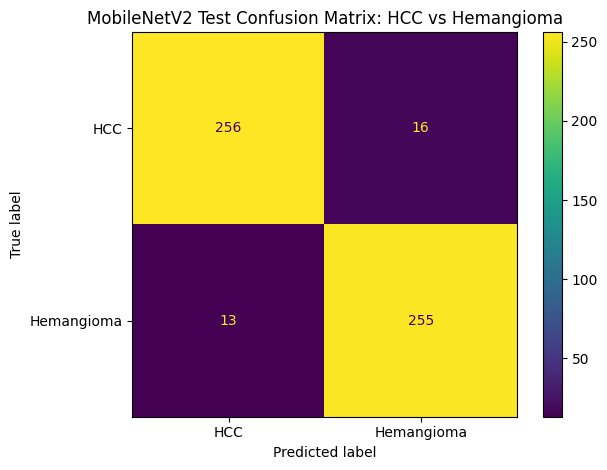

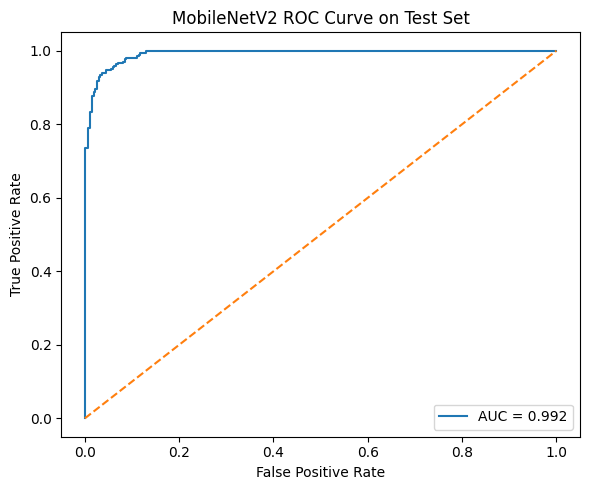

Done.


In [3]:
# =========================
# TRAIN SECOND MODEL: MobileNetV2
# =========================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

# -------------------------
# 1. Check GPU
# -------------------------

print("TensorFlow GPUs:", tf.config.list_physical_devices("GPU"))

# -------------------------
# 2. Define paths and constants
# -------------------------

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 10

train_dir = "/content/drive/MyDrive/split_for_train/train"
val_dir = "/content/drive/MyDrive/split_for_train/val"
test_dir = "/content/drive/MyDrive/split_for_train/test"

# -------------------------
# 3. Load datasets
# -------------------------

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

class_names = train_ds.class_names
print("Class names:", class_names)
print("Important: 0 = HCC, 1 = Hemangioma")

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# -------------------------
# 4. Data augmentation
# -------------------------

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="data_augmentation")

# -------------------------
# 5. Build MobileNetV2 model
# -------------------------

base_model = MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

mobilenet_model = keras.Model(inputs, outputs)

mobilenet_model.summary()

# -------------------------
# 6. Compile model
# -------------------------

mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.AUC(name="auc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

# -------------------------
# 7. Callbacks
# -------------------------

checkpoint_path = "/content/drive/MyDrive/best_mobilenetv2_smc_lud.keras"

callbacks = [
    ModelCheckpoint(
        checkpoint_path,
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=1,
        min_lr=1e-6,
        verbose=1
    )
]

# -------------------------
# 8. Train model
# -------------------------

history_mobilenet = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# -------------------------
# 9. Load best MobileNetV2 model
# -------------------------

best_mobilenet = keras.models.load_model(checkpoint_path)

print("Best MobileNetV2 model loaded.")

# -------------------------
# 10. Predict on test set
# -------------------------

y_true = []
y_prob = []

for images, labels in test_ds:
    probs = best_mobilenet.predict(images, verbose=0)
    y_prob.extend(probs.ravel())
    y_true.extend(labels.numpy().ravel())

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)

y_pred = (y_prob >= 0.5).astype(int)

# -------------------------
# 11. Calculate test metrics
# -------------------------

acc = accuracy_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)

precision_hcc = precision_score(y_true, y_pred, pos_label=0)
recall_hcc = recall_score(y_true, y_pred, pos_label=0)
f1_hcc = f1_score(y_true, y_pred, pos_label=0)

precision_hema = precision_score(y_true, y_pred, pos_label=1)
recall_hema = recall_score(y_true, y_pred, pos_label=1)
f1_hema = f1_score(y_true, y_pred, pos_label=1)

cm = confusion_matrix(y_true, y_pred)

print("\n=========================")
print("MobileNetV2 TEST SET PERFORMANCE")
print("=========================")
print(f"Accuracy: {acc:.4f}")
print(f"AUC: {auc:.4f}")

print("\nHCC metrics:")
print(f"HCC precision: {precision_hcc:.4f}")
print(f"HCC sensitivity/recall: {recall_hcc:.4f}")
print(f"HCC F1-score: {f1_hcc:.4f}")

print("\nHemangioma metrics:")
print(f"Hemangioma precision: {precision_hema:.4f}")
print(f"Hemangioma sensitivity/recall: {recall_hema:.4f}")
print(f"Hemangioma F1-score: {f1_hema:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# -------------------------
# 12. Save results table
# -------------------------

mobilenet_results = pd.DataFrame({
    "Model": ["MobileNetV2"] * 8,
    "Metric": [
        "Accuracy",
        "AUC",
        "HCC Precision",
        "HCC Sensitivity/Recall",
        "HCC F1-score",
        "Hemangioma Precision",
        "Hemangioma Sensitivity/Recall",
        "Hemangioma F1-score"
    ],
    "Value": [
        acc,
        auc,
        precision_hcc,
        recall_hcc,
        f1_hcc,
        precision_hema,
        recall_hema,
        f1_hema
    ]
})

display(mobilenet_results)

mobilenet_results.to_csv("/content/drive/MyDrive/mobilenetv2_smc_lud_test_metrics.csv", index=False)

print("\nMetrics saved to: /content/drive/MyDrive/mobilenetv2_smc_lud_test_metrics.csv")

# -------------------------
# 13. Plot confusion matrix
# -------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(values_format="d")
plt.title("MobileNetV2 Test Confusion Matrix: HCC vs Hemangioma")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/mobilenetv2_smc_lud_confusion_matrix.png", dpi=300)
plt.show()

# -------------------------
# 14. Plot ROC curve
# -------------------------

fpr, tpr, thresholds = roc_curve(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("MobileNetV2 ROC Curve on Test Set")
plt.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/mobilenetv2_smc_lud_roc_curve.png", dpi=300)
plt.show()

print("Done.")

Device: cuda
GPU name: Tesla T4
Class names: ['HCC', 'Hemangioma']
Important: 0 = HCC, 1 = Hemangioma
Train images: 3769
Val images: 1076
Test images: 540


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

ViT model loaded.

Epoch 1/10
------------------------------


/tmp/ipykernel_21858/3384848059.py:177: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_21858/3384848059.py:239: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_21858/3384848059.py:194: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

,epoch,train_loss,train_accuracy,train_auc,val_accuracy,val_auc
0,1,0.163925,0.928628,0.983195,0.992565,0.999960
1,2,0.044203,0.988326,0.997723,0.993494,0.999895
2,3,0.025673,0.992040,0.998888,0.995353,0.999834
3,4,0.012496,0.995490,0.999817,0.993494,0.999903


/tmp/ipykernel_21858/3384848059.py:194: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



ViT-Tiny TEST SET PERFORMANCE
Accuracy: 0.9963
AUC: 1.0000

HCC metrics:
HCC precision: 1.0000
HCC sensitivity/recall: 0.9926
HCC F1-score: 0.9963

Hemangioma metrics:
Hemangioma precision: 0.9926
Hemangioma sensitivity/recall: 1.0000
Hemangioma F1-score: 0.9963

Confusion Matrix:
[[270   2]
 [  0 268]]

Classification Report:
              precision    recall  f1-score   support

         HCC       1.00      0.99      1.00       272
  Hemangioma       0.99      1.00      1.00       268

    accuracy                           1.00       540
   macro avg       1.00      1.00      1.00       540
weighted avg       1.00      1.00      1.00       540



,Model,Metric,Value
0,ViT-Tiny,Accuracy,0.996296
1,ViT-Tiny,AUC,0.999986
2,ViT-Tiny,HCC Precision,1.000000
3,ViT-Tiny,HCC Sensitivity/Recall,0.992647
4,ViT-Tiny,HCC F1-score,0.996310
5,ViT-Tiny,Hemangioma Precision,0.992593
6,ViT-Tiny,Hemangioma Sensitivity/Recall,1.000000
7,ViT-Tiny,Hemangioma F1-score,0.996283



Metrics saved to: /content/drive/MyDrive/vit_tiny_smc_lud_test_metrics.csv


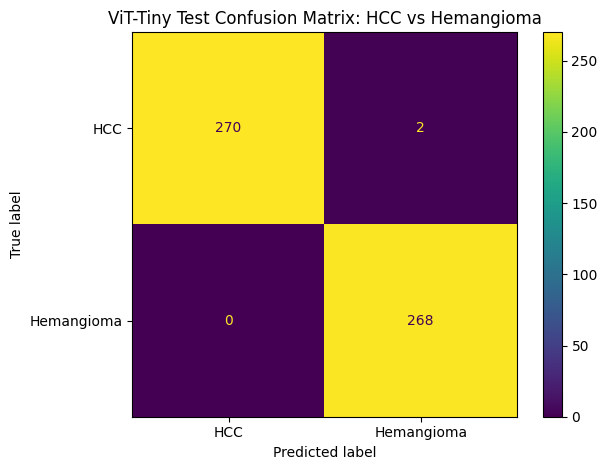

Confusion matrix saved to: /content/drive/MyDrive/vit_tiny_smc_lud_confusion_matrix.png


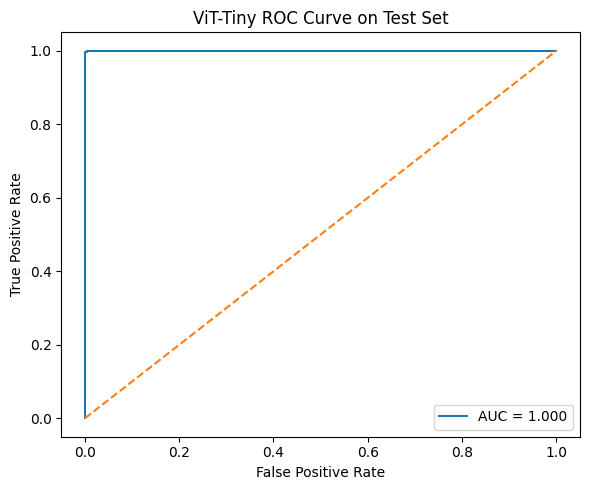

ROC curve saved to: /content/drive/MyDrive/vit_tiny_smc_lud_roc_curve.png
Done.


In [4]:
# =========================
# TRAIN THIRD MODEL: Vision Transformer (ViT-Tiny)
# HCC vs Hemangioma using SMC-LUD Dataset
# =========================

# Install timm if not already installed
!pip install -q timm

import os
import time
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

import timm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

# -------------------------
# 1. Check GPU
# -------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if device.type != "cuda":
    raise RuntimeError("No GPU detected. Stop now and switch Colab runtime to T4 GPU before training ViT.")

print("GPU name:", torch.cuda.get_device_name(0))

# -------------------------
# 2. Reproducibility
# -------------------------

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# -------------------------
# 3. Define paths and constants
# -------------------------

train_dir = "/content/drive/MyDrive/split_for_train/train"
val_dir   = "/content/drive/MyDrive/split_for_train/val"
test_dir  = "/content/drive/MyDrive/split_for_train/test"

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-4
PATIENCE = 3

# -------------------------
# 4. Image transforms
# -------------------------

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(5),
    transforms.ColorJitter(contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# -------------------------
# 5. Load datasets
# -------------------------

train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
val_dataset   = datasets.ImageFolder(val_dir, transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(test_dir, transform=val_test_transforms)

class_names = train_dataset.classes
print("Class names:", class_names)
print("Important: 0 = HCC, 1 = Hemangioma")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train images:", len(train_dataset))
print("Val images:", len(val_dataset))
print("Test images:", len(test_dataset))

# -------------------------
# 6. Build ViT model
# -------------------------

# ViT-Tiny is faster and suitable for comparison.
# You can later change to 'vit_base_patch16_224' if you have stronger GPU time.
model = timm.create_model(
    "vit_tiny_patch16_224",
    pretrained=True,
    num_classes=1
)

model = model.to(device)

print("ViT model loaded.")

# -------------------------
# 7. Loss, optimizer, scheduler
# -------------------------

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.3,
    patience=1
)

# Mixed precision for faster GPU training
scaler = torch.cuda.amp.GradScaler()

# -------------------------
# 8. Helper function: evaluate
# -------------------------

def evaluate_model(model, data_loader):
    model.eval()

    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.float().to(device)

            with torch.cuda.amp.autocast():
                outputs = model(images).squeeze(1)
                probs = torch.sigmoid(outputs)

            all_probs.extend(probs.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    all_labels = np.array(all_labels).astype(int)
    all_probs = np.array(all_probs)

    all_preds = (all_probs >= 0.5).astype(int)

    acc = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)

    return acc, auc, all_labels, all_probs, all_preds

# -------------------------
# 9. Train ViT
# -------------------------

best_val_auc = 0
best_model_wts = copy.deepcopy(model.state_dict())
epochs_without_improvement = 0

history = []

start_time = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 30)

    model.train()

    running_loss = 0.0
    train_labels = []
    train_probs = []

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            outputs = model(images).squeeze(1)
            loss = criterion(outputs, labels)
            probs = torch.sigmoid(outputs)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

        train_labels.extend(labels.detach().cpu().numpy())
        train_probs.extend(probs.detach().cpu().numpy())

    epoch_loss = running_loss / len(train_dataset)

    train_labels = np.array(train_labels).astype(int)
    train_probs = np.array(train_probs)
    train_preds = (train_probs >= 0.5).astype(int)

    train_acc = accuracy_score(train_labels, train_preds)
    train_auc = roc_auc_score(train_labels, train_probs)

    val_acc, val_auc, _, _, _ = evaluate_model(model, val_loader)

    scheduler.step(val_auc)

    print(f"Train Loss: {epoch_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Train AUC: {train_auc:.4f}")
    print(f"Val Accuracy: {val_acc:.4f}")
    print(f"Val AUC: {val_auc:.4f}")

    history.append({
        "epoch": epoch + 1,
        "train_loss": epoch_loss,
        "train_accuracy": train_acc,
        "train_auc": train_auc,
        "val_accuracy": val_acc,
        "val_auc": val_auc
    })

    if val_auc > best_val_auc:
        print(f"Val AUC improved from {best_val_auc:.4f} to {val_auc:.4f}. Saving model.")
        best_val_auc = val_auc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), "/content/drive/MyDrive/best_vit_tiny_smc_lud.pth")
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        print(f"Val AUC did not improve. Patience: {epochs_without_improvement}/{PATIENCE}")

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

training_time = time.time() - start_time
print(f"\nTraining complete in {training_time/60:.2f} minutes.")
print(f"Best validation AUC: {best_val_auc:.4f}")

# Load best weights
model.load_state_dict(best_model_wts)

# Save training history
history_df = pd.DataFrame(history)
history_df.to_csv("/content/drive/MyDrive/vit_tiny_training_history.csv", index=False)
display(history_df)

# -------------------------
# 10. Test best ViT model
# -------------------------

test_acc, test_auc, y_true, y_prob, y_pred = evaluate_model(model, test_loader)

precision_hcc = precision_score(y_true, y_pred, pos_label=0)
recall_hcc = recall_score(y_true, y_pred, pos_label=0)
f1_hcc = f1_score(y_true, y_pred, pos_label=0)

precision_hema = precision_score(y_true, y_pred, pos_label=1)
recall_hema = recall_score(y_true, y_pred, pos_label=1)
f1_hema = f1_score(y_true, y_pred, pos_label=1)

cm = confusion_matrix(y_true, y_pred)

print("\n=========================")
print("ViT-Tiny TEST SET PERFORMANCE")
print("=========================")
print(f"Accuracy: {test_acc:.4f}")
print(f"AUC: {test_auc:.4f}")

print("\nHCC metrics:")
print(f"HCC precision: {precision_hcc:.4f}")
print(f"HCC sensitivity/recall: {recall_hcc:.4f}")
print(f"HCC F1-score: {f1_hcc:.4f}")

print("\nHemangioma metrics:")
print(f"Hemangioma precision: {precision_hema:.4f}")
print(f"Hemangioma sensitivity/recall: {recall_hema:.4f}")
print(f"Hemangioma F1-score: {f1_hema:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# -------------------------
# 11. Save results table
# -------------------------

vit_results = pd.DataFrame({
    "Model": ["ViT-Tiny"] * 8,
    "Metric": [
        "Accuracy",
        "AUC",
        "HCC Precision",
        "HCC Sensitivity/Recall",
        "HCC F1-score",
        "Hemangioma Precision",
        "Hemangioma Sensitivity/Recall",
        "Hemangioma F1-score"
    ],
    "Value": [
        test_acc,
        test_auc,
        precision_hcc,
        recall_hcc,
        f1_hcc,
        precision_hema,
        recall_hema,
        f1_hema
    ]
})

display(vit_results)

vit_results.to_csv("/content/drive/MyDrive/vit_tiny_smc_lud_test_metrics.csv", index=False)
print("\nMetrics saved to: /content/drive/MyDrive/vit_tiny_smc_lud_test_metrics.csv")

# -------------------------
# 12. Plot confusion matrix
# -------------------------

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(values_format="d")
plt.title("ViT-Tiny Test Confusion Matrix: HCC vs Hemangioma")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/vit_tiny_smc_lud_confusion_matrix.png", dpi=300)
plt.show()

print("Confusion matrix saved to: /content/drive/MyDrive/vit_tiny_smc_lud_confusion_matrix.png")

# -------------------------
# 13. Plot ROC curve
# -------------------------

fpr, tpr, thresholds = roc_curve(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {test_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ViT-Tiny ROC Curve on Test Set")
plt.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/vit_tiny_smc_lud_roc_curve.png", dpi=300)
plt.show()

print("ROC curve saved to: /content/drive/MyDrive/vit_tiny_smc_lud_roc_curve.png")
print("Done.")

In [5]:
# =========================
# CHECK MISSED HCC CASES AND CONFIDENCE - ViT-Tiny
# =========================

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Make sure model is in evaluation mode
model.eval()

missed_hcc_cases = []

# ImageFolder stores file paths here
test_image_paths = [sample[0] for sample in test_dataset.samples]

all_index = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        with torch.cuda.amp.autocast():
            outputs = model(images).squeeze(1)
            probs_hema = torch.sigmoid(outputs)

        probs_hema = probs_hema.detach().cpu().numpy()
        labels_np = labels.detach().cpu().numpy().astype(int)

        # Prediction: probability >= 0.5 means Hemangioma
        preds = (probs_hema >= 0.5).astype(int)

        for i in range(len(labels_np)):
            true_label = labels_np[i]
            pred_label = preds[i]
            prob_hema = probs_hema[i]
            prob_hcc = 1 - prob_hema

            # Missed HCC = true HCC but predicted Hemangioma
            if true_label == 0 and pred_label == 1:
                missed_hcc_cases.append({
                    "index": all_index,
                    "image_path": test_image_paths[all_index],
                    "true_label": "HCC",
                    "predicted_label": "Hemangioma",
                    "probability_HCC": prob_hcc,
                    "probability_Hemangioma": prob_hema,
                    "confidence_in_wrong_prediction": prob_hema
                })

            all_index += 1

missed_hcc_df = pd.DataFrame(missed_hcc_cases)

print("Number of missed HCC cases:", len(missed_hcc_df))
display(missed_hcc_df)

# Save missed cases table
missed_hcc_df.to_csv("/content/drive/MyDrive/vit_tiny_missed_hcc_cases.csv", index=False)
print("Saved to: /content/drive/MyDrive/vit_tiny_missed_hcc_cases.csv")

/tmp/ipykernel_21858/2371582594.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Number of missed HCC cases: 2


/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,index,image_path,true_label,predicted_label,probability_HCC,probability_Hemangioma,confidence_in_wrong_prediction
0,74,/content/drive/MyDrive/split_for_train/test/HC...,HCC,Hemangioma,0.438965,0.561035,0.561035
1,76,/content/drive/MyDrive/split_for_train/test/HC...,HCC,Hemangioma,0.142578,0.857422,0.857422


Saved to: /content/drive/MyDrive/vit_tiny_missed_hcc_cases.csv
